## Chapter 06 - Making Decisions and Predictions with Linear Regression

In this notebook we'll lean how to:
- Fit a line to data with the `ols()`function.
- Calculate the Sum of the Squared Residuals (SSR) and $R^2$.
- Generating a Linear Regression Summary with `results.summary()`.
- Calculating a *p*-value for the $R^2$ using the null hypothesis to build a histogram.
- Calculate an *F*-valu and corresponding *p*-value using the Sum of the Squared Residuals (SSR).

In [7]:
# Loading in required libraries for running code
import numpy as np # to generate random numbers
import pandas as pd # to use DataFrames
import seaborn as sns # to draw graphs
import matplotlib.pyplot as plt # give us control of the x-y axis range

import statsmodels.formula.api as smf # to dol innear regressions with ols()

# Fitting a line to data with the `ols()` function

If we´re going to fit a line to some data, tehn the first thing we need is some data. In this example we´ll use the dataset illustrated in Chapter 6, which has the number of stores in one column, and the revenue in another.

In [10]:
# First, let's put the data into a DataFrame
num_stores = [2, 12, 15]
revenue = [3, 12.5, 7]

data = pd.DataFrame({
    'num_stores' : num_stores,
    'revenue' : revenue
})

data

,num_stores,revenue
0,2,3.0
1,12,12.5
2,15,7.0


(0.0, 16.0)

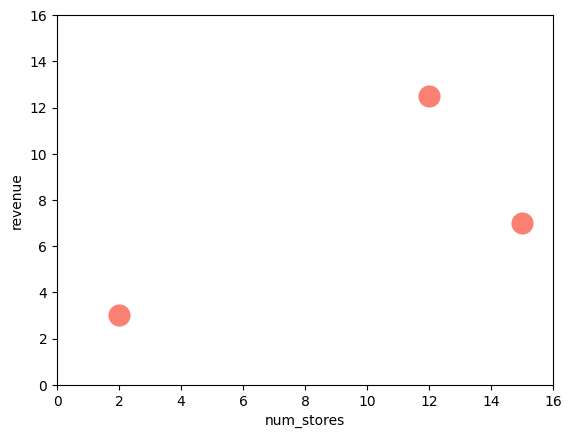

In [11]:
my_plot = sns.scatterplot(x='num_stores',
                          y='revenue',
                          data=data,
                          s=300, # scale the size of the points
                          color='salmon')
plt.xlim(0,16)
plt.ylim(0,16)

Now that we have plotted our data, let´s add a linear regression line to it. This requires two steps. First, we need to determine the slope and y-axis intercept, for the linear regression line, and second, we use this slope and y-axis intercept to draw a line on the graph.

In [ ]:
# We'll start by determining the slope and y-axis intercept. Here, the 
# `old()` function will return an object that we can use to fit a linear 
# regression model to our data, and print the result.

## First, create the model object.
# Here, the 'thing we want to predict' comes before the '~', and 
# the 'variables we want to use to make the prediction' comes after
# the '~'.
model = smf.ols("revenue ~ num_stores", data=data)

Now that we have created an ordinary least squares model, called `model`, we can fit it to our data.

In [14]:
## Now fit the model to the data (optimize the 2 parameters, the y-axis 
## intercept and the slope)
results = model.fit()

...and then print out the values for the y-axis intercept and the slope with
`results.params`.

In [ ]:
print(results.params, "\n")

print(
    "Intercept : ", "\n",
    results.params.Intercept, "\n", "\n",
    "Slope 'num_stores' : ", "\n",
    results.params.num_stores
)

Intercept     2.962230
num_stores    0.469424
dtype: float64 

Intercept :  
 2.962230215827336 
 
Slope 'num_stores' :  
 0.46942446043165487


Now, if we want to add the linear regression line to our graph of the data,
we can do that with the `abline()` function. `abline()` makes this much easier, by having an argument called `reg` that we can pass `lr.line` to – facilitating the drawing of the line.

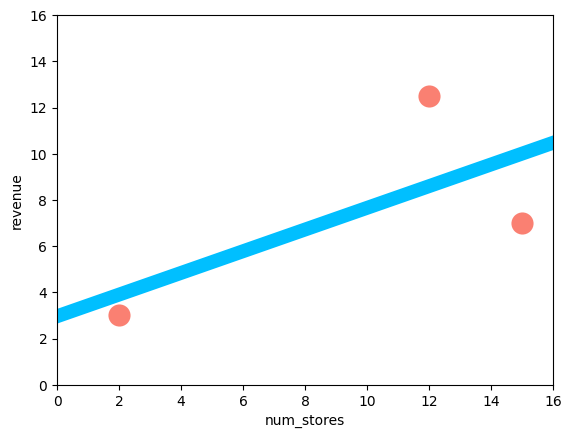

In [26]:
## First, draw the data...
my_plot = sns.scatterplot(
    x='num_stores',
    y='revenue',
    data=data,
    s=300,
    color='salmon'
)

plt.xlim(0, 16)
plt.ylim(0, 16)

## ...and add the regression line.
my_plot.axline(
    xy1 = (0, results.params.Intercept),
    slope = results.params.num_stores,
    color = 'deepskyblue',
    linestyle = "-",
    linewidth = 10
)

Now that we have a graph of our data, and it's corresponding linear regression
line, let´s learn how to interpret the statistics associated with the 
linear regression.

## Generating a Linear Regression Summary with `summary()`

Earlier, when we printed the output from `ols()` that we saved in `results`, we
specifically printed out the y-axis intercept, and the slope. However,
`results` contains a lot more data that we can access by using its 
`summary()` method.

In [27]:
## Now, print out the assoicated statistics from the OLS-Linear Regression.
results.summary()

/Users/albertadlersson/Library/Python/3.9/lib/python/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                 -0.102
Method:                 Least Squares   F-statistic:                    0.8142
Date:                Sun, 30 Aug 2026   Prob (F-statistic):              0.533
Time:                        17:48:17   Log-Likelihood:                -7.4420
No. Observations:                   3   AIC:                             18.88
Df Residuals:                       1   BIC:                             17.08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9622      5.801      0.511      0.699     -70.745      76.670
num_stores     0.4694      0.520      0.902      0.533      -6.141       7.080
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.824
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.377
Skew:                           0.437   Prob(JB):                        0.828
Kurtosis:                       1.500   Cond. No.                         22.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

As we can see, the output from `summary()` is extensive. Right now, we just want to know the $R^2$ and it´s associated *p*-value. We can find the value for $R^2$ in the upper right hand corner, and see that it is 0.449. The corresponding *p*-value is a few rows down and is 0.533.

Using the standard threshold for statistical significance, 0.05, we would fail to reject the Null Hypothesis that there is no relationship between 'the number of stores a company has', and it's 'revenue'. Although, we have very little data, so we can´t know if the same results would hold given more data.

To directly access $R^2$, use the following command `results.rsquared`.


In [29]:
## summary() returns 3 tables.
summary_stuff = results.summary()

## Print out the second one, it has everything related to coefficients.
summary_stuff.tables[1]

/Users/albertadlersson/Library/Python/3.9/lib/python/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.9622,5.801,0.511,0.699,-70.745,76.670
num_stores,0.4694,0.520,0.902,0.533,-6.141,7.080


As we can see, when we print out the coefficients, we get all kinds of information 
in addition to the values for the y-axis intercepts, and the slope. The next two 
columbs **std err** abd **t**, are not super interesting right now, but the 
second to the last column **P(>|t|)** is. This tells us that the *p*-value for each
parameter testing the Null Hypothesis that the parameter value is actually 0.

For example, for the estimated y-axis intercept that we calculated from the data,
is 2.9622, however the *p*-value that test the hypothesis that it actually is
equal to 0, is 0.699. This tells us that even though our estimate for the y-axis 
intercept is non-zero, we can´t be confident that it reall is non-zero.

In other words, we fail to reject the hypothesis that just using the mean value 
for Revenye (which we would use if the slope was 0), is significantly 
worse than using the linear regression line.

In [30]:
## Retrieving the p-value only.
results.pvalues.num_stores

np.float64(0.5326582987917048)

In [31]:
## Retrieving the p-value only, second method.
results.pvalues.iloc[1]

np.float64(0.5326582987917048)

Anyway, now that we know how to do a linear regression with `lm()` and access and interpret the most important results, let´s try to calculate some of these values by hand. We'll start by calculating $R^2$.

## Calculating the Sum of the Squared Residuals (SSRs) and $R^2$

Even though the `lm()` function calculated $R^2$, it's also helpful to know how to calculate it both by hand. The equation for $R^2$ is:

$$R^2 = \frac{\textrm{SSR(mean)} - \textrm{SSR(fit)}}{\textrm{SSR(mean)}}$$

Where SSR(mean) is the Sum of the Squared Residuals around the mean y-axis value, which, in this example, is Revenue, and SSR(fit) is the Sum of the Squared Residuals around the fitted line.


In [53]:
## calculate mean revenue
mean_revenue = np.mean(data['revenue'])
print("mean revenue:", mean_revenue, "\n")

## Calculate the residuals from the mean
mean_residuals = data['revenue'] - mean_revenue
print("mean residuals:", "\n", mean_residuals, "\n")

## Square each residuals
mean_residuals_squared = mean_residuals ** 2
print("mean residuals, squared:", "\n", mean_residuals_squared, "\n")

## Add up the squared residuals
ssr_mean = np.sum(mean_residuals_squared)

## print out the SSR(mean)
print("SSR(mean):", ssr_mean)

mean revenue: 7.5 

mean residuals: 
 0   -4.5
1    5.0
2   -0.5
Name: revenue, dtype: float64 

mean residuals, squared: 
 0    20.25
1    25.00
2     0.25
Name: revenue, dtype: float64 

SSR(mean): 45.5


Now, we calculate SSR(fit).

In [49]:
fit_predictions = results.params.Intercept + (results.params.num_stores * data['num_stores'])
print("Fit predicitons:", "\n", fit_predictions, "\n")

fit_residuals = data.revenue - fit_predictions
print("Fit residuals:", "\n", fit_residuals, "\n")

# Compare to the already calculated results
results.resid

Fit predicitons: 
 0     3.901079
1     8.595324
2    10.003597
Name: num_stores, dtype: float64 

Fit residuals: 
 0   -0.901079
1    3.904676
2   -3.003597
dtype: float64 



0   -0.901079
1    3.904676
2   -3.003597
dtype: float64

Let's finis calculating the SSR(fit)!

In [51]:
## Sqaure the residuals
fit_residuals_squared = fit_residuals ** 2
print(fit_residuals_squared, "\n")

## Add the squared residuals
ssr_fit = np.sum(fit_residuals_squared)
print(ssr_fit)

0     0.811944
1    15.246497
2     9.021596
dtype: float64 

25.080035971223026


Now that we have both SSR(mean) and SSR(fit), we can calculate $R^2$.

In [57]:
## R-squared
r_squared = (ssr_mean - ssr_fit) / ssr_mean
print(r_squared, "\n")

## Compare with answer sheet
results.rsquared

0.44879041821487853 



np.float64(0.44879041821487853)

## Calculating a *p*-value for the $R^2$, with a histogram

Now that we know how to fit a linear regression line to data with `ols()` and calculate the $R^2$ value with `summary()`, and by hand, we are ready to learn how to calculate the *p*-value for the $R^2$ using a histogram. 

This requires that we repeat:
- Generating random data
- Fit a line to the data usin `ols()`
- Calculate the $R^2$ value for that fit with `summary()`
- Store the $R^2$ value in an array, in order to accumulate it´s probability distribution.

Once we have an array of $R^2$ values, calculated from random dataset, we pass it to `hjistplot()` to see how they are distributed, so that we can calculate a *p*-value based on how many of the random $R^2$ values are greater than the one for our original dataset.

We'll start by generating the random $R^2$ values with the followin code:

In [59]:
np.random.seed(2)

mean_num_stores = data['num_stores'].mean()
sd_num_stores = data['num_stores'].std()

mean_revenue = data['revenue'].mean()
sd_revenue = data['revenue'].std()

num_rand_datasets = 10_000
num_datapoints = len(data)

rand_r_squared = np.empty(num_rand_datasets)

for i in range(num_rand_datasets):

    rand_num_stores = np.random.normal(
        loc = mean_num_stores,
        scale = sd_num_stores,
        size = num_datapoints
    )

    rand_revenue = np.random.normal(
        loc = mean_revenue,
        scale = sd_revenue,
        size = num_datapoints
    )

    rand_data = pd.DataFrame({
        'rand_num_stores': rand_num_stores,
        'rand_revenue': rand_revenue
    })

    rand_model = smf.ols("rand_revenue ~ rand_num_stores", data = rand_data)
    rand_results = rand_model.fit()

    rand_r_squared[i] = rand_results.rsquared

np.float64(0.5305)

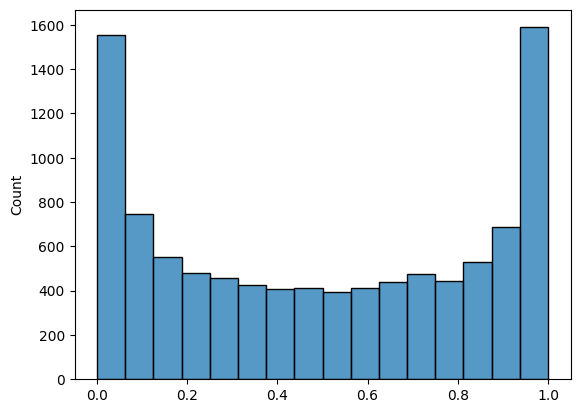

In [60]:
sns.histplot(data = rand_r_squared)

# the number of randomly generated rsquared >= the original rsquared
num_greater = np.sum(rand_r_squared >= results.rsquared)

p_value = num_greater / num_rand_datasets

p_value

In [61]:
results.pvalues.num_stores

np.float64(0.5326582987917048)

## Calculate an *F*-value and *p*-value using the Sum of the Squared Residuals (SSR)

The equation for *F* is:

$$F = \frac{[\textrm{SSR(mean)} - \textrm{SSR(fit)}] / (p_\textrm{fit} - p_\textrm{mean})}
    {\textrm{SSR(fit)} / (n - p_\textrm{fit})}$$

...so, all we have to do to calculate *F* is to plug in the SSR(mean), the SSR(fit), *p_fit*, the number of parameters required for the fitted line, *p_mean*, and *n*.

In [62]:
F_numerator = (ssr_mean - ssr_fit) / (2 - 1)
F_denominator = ssr_fit / (3 - 2)


In [63]:
F = F_numerator / F_denominator
F

np.float64(0.8141919753307753)

In [64]:
results.fvalue

np.float64(0.8141919753307753)

In [66]:
## Let's convert that F-value into a p-value

from scipy.stats import f

# `f.cdf()` only calculates cumulative probability values to the *lef* of a 
# specified x-axis coordinate. To get the probability to the *right*, we take
# 1 minus all that is to the *left*
p_value_f = 1 - f.cdf(x = F, dfn=(2-1), dfd=(3-2))
p_value_f

np.float64(0.5326582987917045)

In [67]:
results.pvalues.num_stores

np.float64(0.5326582987917048)